# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

Used car dealerships have to compete hard to win customers and make a profit. They need to find a balance between keeping prices low enough for buyers to afford, but high enough to keep the business running. Many things change how much a car is worth, especially how old it is, how many miles it has, its condition, the brand, and the type of fuel it uses.

Knowing how these factors connect helps dealerships set fair prices, buy the right cars to sell and offer fair trade-in values. On top of that, shopping habits change depending on the time of year, the local area, and how the overall economy is doing. By learning what matters most to buyers, dealerships can improve their marketing, sell more cars, and make better business decisions that keep customers happy.

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [135]:
#Loading the vehicles dataset
df = pd.read_csv('data/vehicles.csv')

In [136]:
#Read the loaded dataset
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [137]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [138]:
# Calculate counts and percentages of missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

df_missing = pd.DataFrame({
    "Feature": missing_counts.index,
    "Missing Values": missing_counts.values,
    "Percentage": missing_pct.values
})

df_missing = df_missing[df_missing["Missing Values"] > 0].sort_values(by="Percentage", ascending=False)

df_missing

,Feature,Missing Values,Percentage
14,size,306361,71.767476
7,cylinders,177678,41.622470
6,condition,174104,40.785232
12,VIN,161042,37.725356
13,drive,130567,30.586347
16,paint_color,130203,30.501078
15,type,92858,21.752717
4,manufacturer,17646,4.133714
10,title_status,8242,1.930753
5,model,5277,1.236179


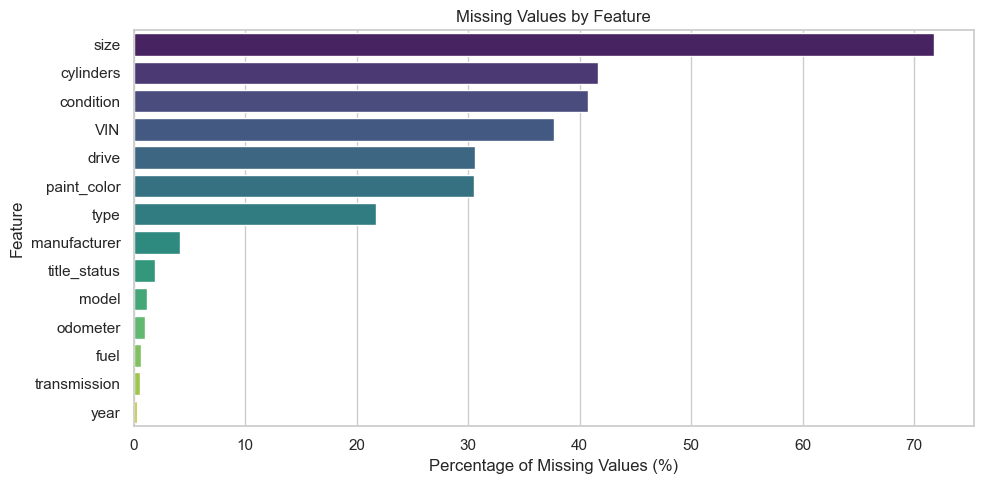

In [140]:
# Plot Missing Values by Feature
plt.figure(figsize=(10, 5))
sns.barplot(
    x="Percentage", 
    y="Feature", 
    data=df_missing, 
    hue="Feature",      
    palette="viridis",  
    legend=False
)

plt.xlabel("Percentage of Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")
plt.tight_layout()
plt.show()

1. size has alot of missing values should be deleted.
2. id, and VIN are unique values should be deleted.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [141]:
# Creates a copy of the original dataset
data_cleaned = df.copy()

In [142]:
# Drops unnecessary columns
data_cleaned.drop(columns=['VIN', 'size', 'id'], inplace=True)

In [143]:
#Fix data and data type issues
data_cleaned['price'] = pd.to_numeric(data_cleaned['price'])
data_cleaned['year'] = pd.to_numeric(data_cleaned['year'])
data_cleaned['odometer'] = pd.to_numeric(data_cleaned['odometer'])

data_cleaned = data_cleaned.dropna(subset=['price', 'year', 'odometer'])
data_cleaned['year'] = data_cleaned['year'].astype(int)

In [144]:
#Min and max for price
data_cleaned['price'].describe()

count    4.213440e+05
mean     7.598356e+04
std      1.226205e+07
min      0.000000e+00
25%      5.975000e+03
50%      1.398800e+04
75%      2.649500e+04
max      3.736929e+09
Name: price, dtype: float64

In [145]:
#Min and max for odometer
data_cleaned['odometer'].describe()

count    4.213440e+05
mean     9.822513e+04
std      2.141207e+05
min      0.000000e+00
25%      3.795100e+04
50%      8.582750e+04
75%      1.338000e+05
max      1.000000e+07
Name: odometer, dtype: float64

In [146]:
#Min and max for year
data_cleaned['year'].describe()

count    421344.000000
mean       2011.225244
std           9.463345
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

In [147]:
# Removing unwanted noise
data_cleaned = data_cleaned[
    (data_cleaned['price'] >= 2000) & (data_cleaned['price'] <= 60000) &
    (data_cleaned['odometer'] > 100) & (data_cleaned['odometer'] <= 250000) &
    (data_cleaned['year'] >= 2000) & (data_cleaned['year'] <= 2022)
].copy()

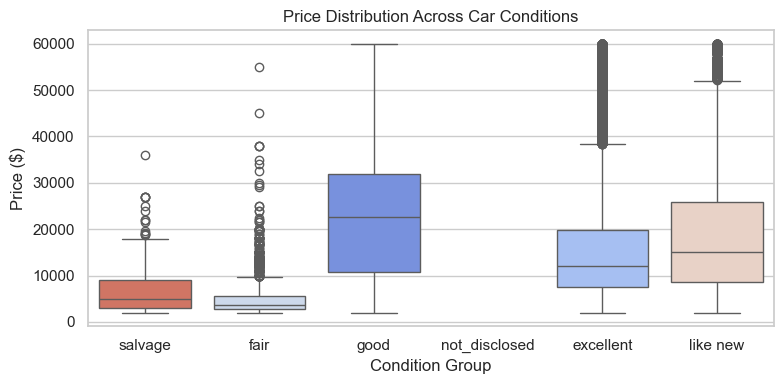

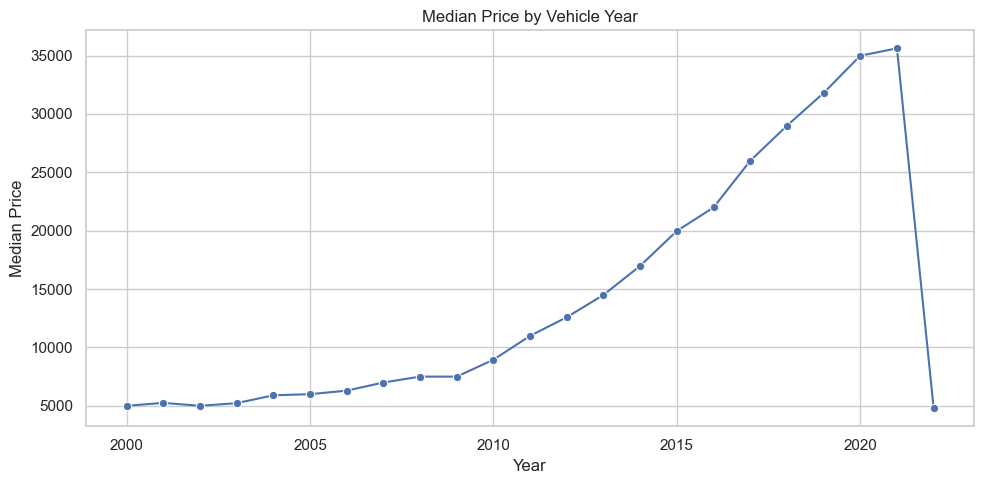

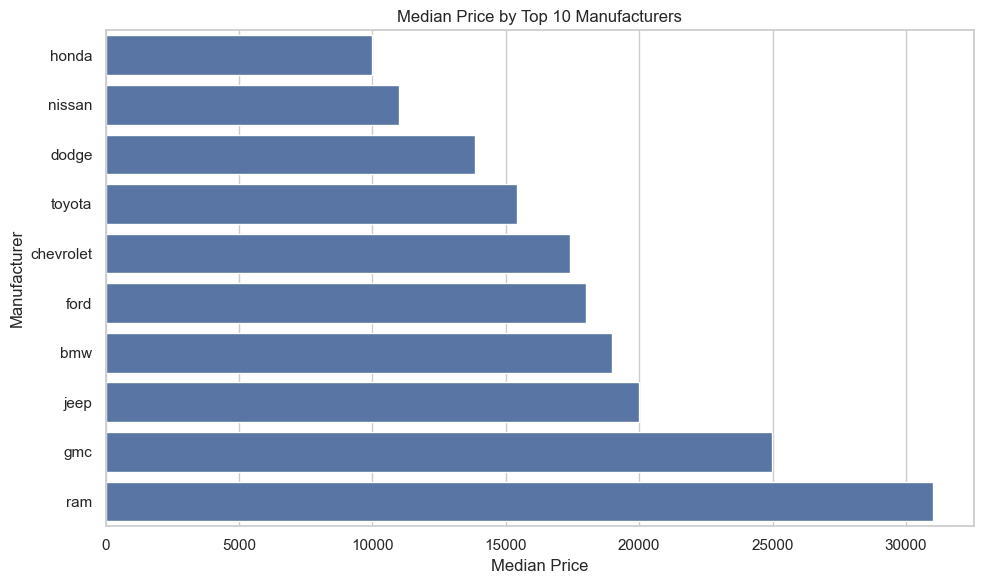

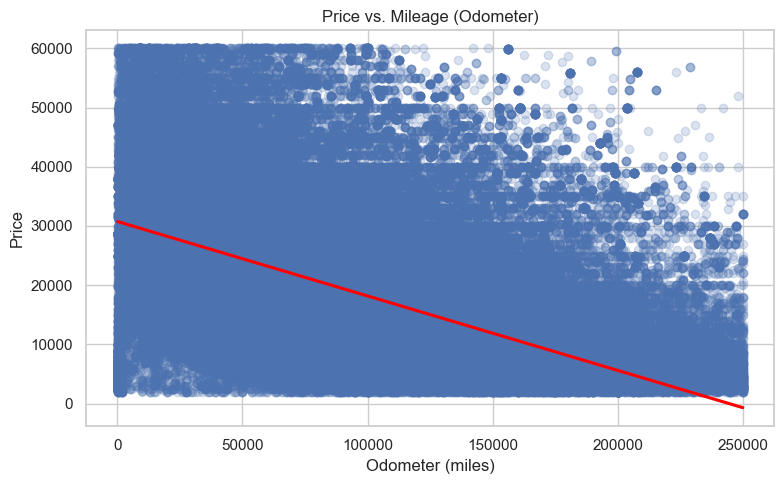

In [148]:
### Plotting Visualizations 

#  Price vs. Condition Bracket
plt.figure(figsize=(8, 4))
condition_order = ['salvage', 'fair', 'good', 'not_disclosed', 'excellent', 'like new']
sns.boxplot(x='condition', y='price', data=data_cleaned, order=condition_order, hue='condition', palette="coolwarm", legend=False)
plt.title('Price Distribution Across Car Conditions')
plt.xlabel('Condition Group')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

# Price vs. Year (Aggregate)
year_price = data_cleaned.groupby('year')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='year', y='price', data=year_price, marker='o')
plt.title('Median Price by Vehicle Year')
plt.xlabel('Year')
plt.ylabel('Median Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Top 10 Manufacturers by Volume and Their Median Prices
top_makes = data_cleaned['manufacturer'].value_counts().nlargest(10).index
make_price = data_cleaned[data_cleaned['manufacturer'].isin(top_makes)].groupby('manufacturer')['price'].median().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=make_price.values, y=make_price.index)
plt.title('Median Price by Top 10 Manufacturers')
plt.xlabel('Median Price')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.show()

# Price vs. Odometer (Trend Line)
plt.figure(figsize=(8, 5))
sns.regplot(x='odometer', y='price', data=data_cleaned, scatter_kws={'alpha':0.2}, line_kws={"color": "red"})
plt.title('Price vs. Mileage (Odometer)')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [150]:
# Get the raw counts of each condition
condition_counts = data_cleaned['condition'].value_counts()
print(condition_counts)

condition
good         106831
excellent     81518
like new      17358
fair           2548
new             585
salvage         224
Name: count, dtype: int64


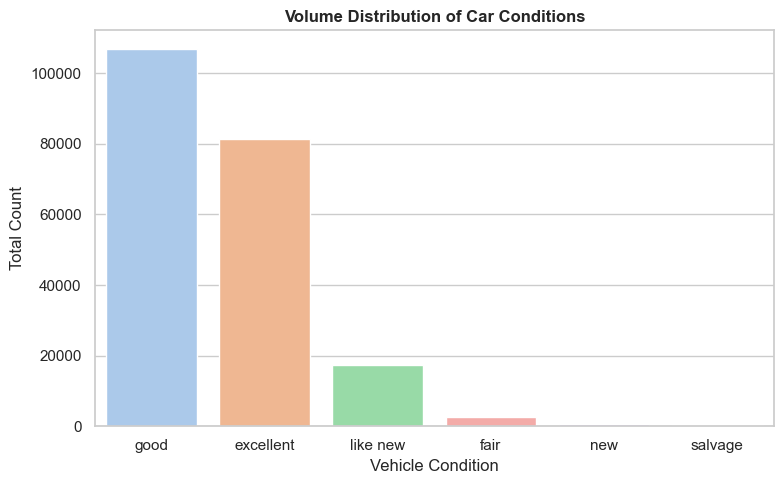

In [151]:
# Distribution of Car Conditions
plt.figure(figsize=(8, 5))

sns.barplot(
    x=condition_counts.index, 
    y=condition_counts.values, 
    hue=condition_counts.index,
    palette='pastel',
    legend=False
)

plt.title('Volume Distribution of Car Conditions', fontsize=12, weight='bold')
plt.xlabel('Vehicle Condition')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

1. New cars have the highest price but make up a tiny portion of the dataset.
2. Good condition cars are priced higher than Excellent, suggesting variations in how condition is labeled or differences in manufacturer value.
3. Salvage and Fair condition cars suffer a massive price drop, indicating that buyers place heavy importance on vehicle history and condition.

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [152]:
# Train and Test data
X = data_cleaned.drop(columns=['price', 'model', 'region'], errors='ignore') 

y = data_cleaned['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [153]:
# Define column types and preprocessing steps
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'type']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# collect metrics from each individual models
model_metrics = {}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [154]:
# Create and train the Linear Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_test_real = y_test


lr_mse = mean_squared_error(y_test_real, y_pred_lr)
lr_mae = mean_absolute_error(y_test_real, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test_real, y_pred_lr)

model_metrics['Linear Regression'] = {
    'MSE': round(lr_mse, 2),
    'MAE': round(lr_mae, 2),
    'RMSE': round(lr_rmse, 2),
    'R2': round(lr_r2, 4)
}

print("Linear Regression Results")
print(f"R2 Score: {lr_r2:.4f}")
print(f"MAE:      {lr_mae:.2f}")
print(f"MSE:      {lr_mse:.2f}")
print(f"RMSE:     {lr_rmse:.2f}")

Linear Regression Results
R2 Score: 0.7256
MAE:      4962.02
MSE:      44403056.53
RMSE:     6663.56


In [155]:
# Predict best alpha for ridge regression

alpha_grid = [0.01, 0.1, 1.0, 10.0]

ridge_pipe = Pipeline([
    ('transformer', preprocessor),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_param_grid = {
    'ridge__alpha': alpha_grid
}

grid_ridge = GridSearchCV(ridge_pipe, param_grid=ridge_param_grid, cv=5, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

print(f"Best Ridge Alpha: {grid_ridge.best_params_['ridge__alpha']}")

Best Ridge Alpha: 10.0


In [165]:
# Predict best alpha for lasso regression

alpha_grid = [0.01, 0.1, 1.0, 10.0]
lasso_pipe = Pipeline([
    ('transformer', preprocessor),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=5000, tol=0.1)) 
])

lasso_param_grid = {
    'lasso__alpha': alpha_grid
}

grid_lasso = GridSearchCV(lasso_pipe, param_grid=lasso_param_grid, cv=5, n_jobs=-1)
grid_lasso.fit(X_train, y_train)

print(f"Best Lasso Alpha: {grid_lasso.best_params_['lasso__alpha']}")

Best Lasso Alpha: 0.1


In [157]:
# Create and train the Ridge Regression pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_ridge = ridge_pipeline.predict(X_test)
y_test_real = y_test

ridge_mse = mean_squared_error(y_test_real, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test_real, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test_real, y_pred_ridge)

model_metrics['Ridge (Alpha=10.0)'] = {
    'MSE': round(ridge_mse, 2),
    'MAE': round(ridge_mae, 2),
    'RMSE': round(ridge_rmse, 2),
    'R2': round(ridge_r2, 4)
}

print("Ridge Regression Results")
print(f"R2 Score: {ridge_r2:.4f}")
print(f"MAE:      {ridge_mae:.2f}")
print(f"MSE:      {ridge_mse:.2f}")
print(f"RMSE:     {ridge_rmse:.2f}")

Ridge Regression Results
R2 Score: 0.7255
MAE:      4962.54
MSE:      44415085.22
RMSE:     6664.46


In [158]:
# Create and train the Lasso Regression pipeline
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1, max_iter=5000, tol=0.1))
])

lasso_pipeline.fit(X_train, y_train)

y_pred_lasso = lasso_pipeline.predict(X_test)
y_test_real = y_test

lasso_mse = mean_squared_error(y_test_real, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test_real, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test_real, y_pred_lasso)

model_metrics['Lasso (Alpha=0.1)'] = {
    'MSE': round(lasso_mse, 2),
    'MAE': round(lasso_mae, 2),
    'RMSE': round(lasso_rmse, 2),
    'R2': round(lasso_r2, 4)
}

print(" Lasso Regression Results")
print(f"R2 Score: {lasso_r2:.4f}")
print(f"MAE:      {lasso_mae:.2f}")
print(f"MSE:      {lasso_mse:.2f}")
print(f"RMSE:     {lasso_rmse:.2f}")

 Lasso Regression Results
R2 Score: 0.7255
MAE:      4962.21
MSE:      44407536.45
RMSE:     6663.90


In [133]:
# Convert gathered dictionary results into a final comparison DataFrame
df_results = pd.DataFrame.from_dict(model_metrics, orient='index')
df_results = df_results.reset_index().rename(columns={'index': 'Model'})

print("FINAL MODEL PERFORMANCE SUMMARY")
print(df_results.to_string(index=False))

FINAL MODEL PERFORMANCE SUMMARY
             Model         MSE     MAE    RMSE     R2
 Linear Regression 44403056.53 4962.02 6663.56 0.7256
Ridge (Alpha=10.0) 44415085.22 4962.54 6664.46 0.7255
 Lasso (Alpha=0.1) 44407536.45 4962.21 6663.90 0.7255


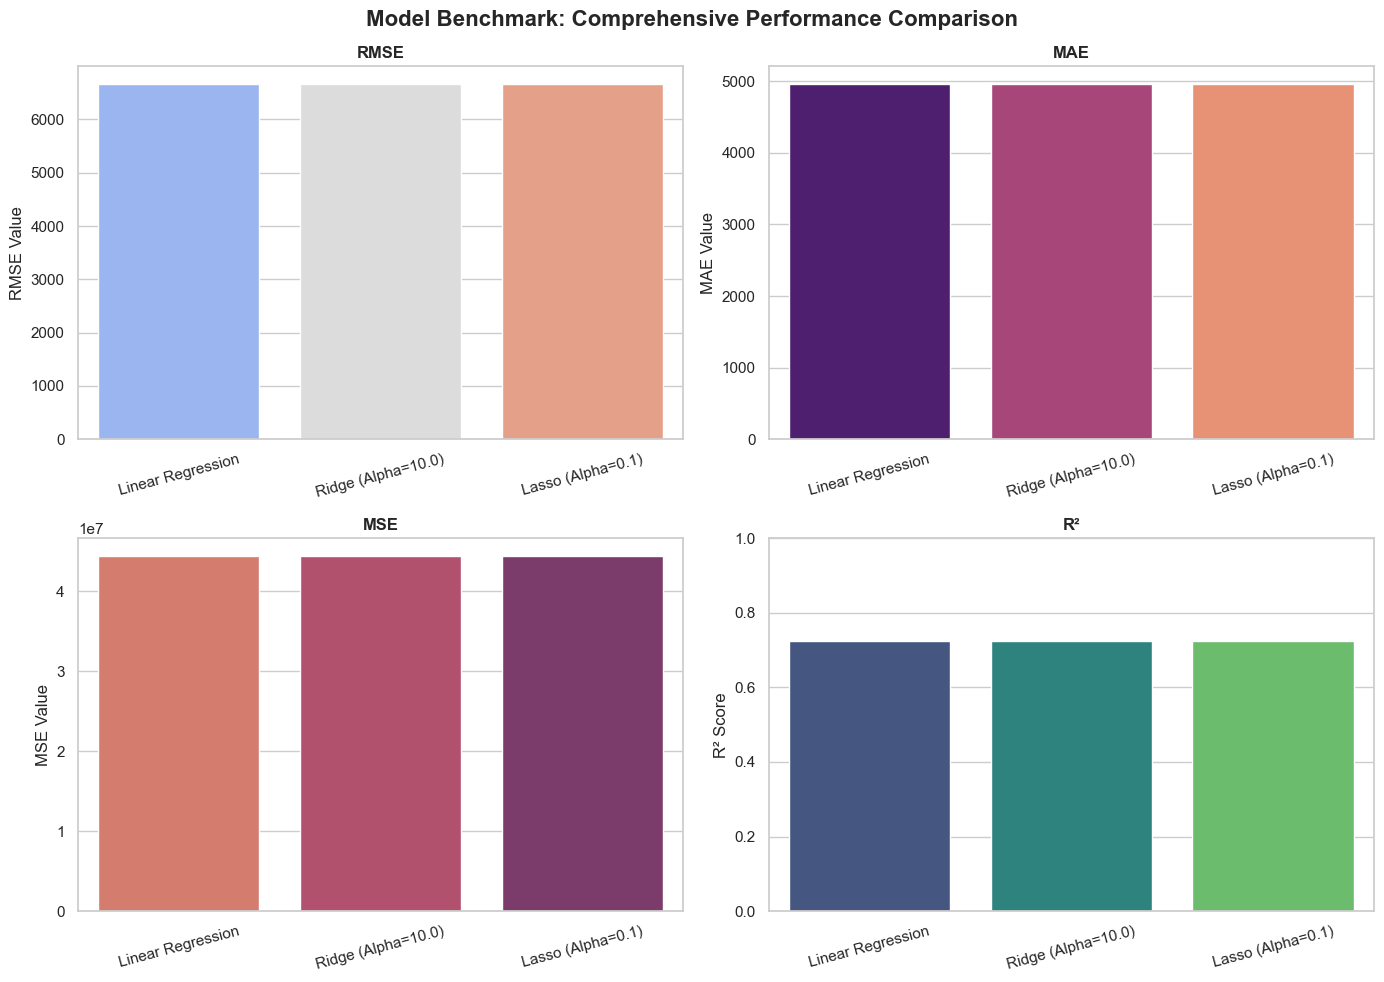

In [160]:
# Plotting MSE,MAE,RMSE,R2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Root Mean Squared Error (RMSE) 

sns.barplot(
    x='Model', 
    y='RMSE', 
    data=df_results, 
    hue='Model',
    palette='coolwarm', 
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title('RMSE', fontsize=12, weight='bold')
axes[0, 0].set_ylabel('RMSE Value')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=15)

#  Mean Absolute Error (MAE) 

sns.barplot(
    x='Model', 
    y='MAE', 
    data=df_results, 
    hue='Model',
    palette='magma', 
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title('MAE', fontsize=12, weight='bold')
axes[0, 1].set_ylabel('MAE Value')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=15)

#  Mean Squared Error (MSE) 
sns.barplot(
    x='Model', 
    y='MSE', 
    data=df_results, 
    hue='Model',
    palette='flare', 
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title('MSE', fontsize=12, weight='bold')
axes[1, 0].set_ylabel('MSE Value')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=15)

#  R² Score (R-squared) 

sns.barplot(
    x='Model', 
    y='R2', 
    data=df_results, 
    hue='Model',
    palette='viridis', 
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title('R²', fontsize=12, weight='bold')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylim(0, 1.0)  
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Benchmark: Comprehensive Performance Comparison', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Clear Identification 
Our primary evaluation metric for this model benchmark is **Mean Absolute Error (MAE)**. We also track **Root Mean Squared Error (RMSE)** and $R^2$ as secondary metrics to monitor variance and penalize larger prediction outliers.

### Rationale (Why MAE is the Best Choice Here) 
We chose MAE as our main score because it makes sense in the real world. Other math metrics (like MSE) square the mistakes, which leaves you with confusing numbers like "dollars squared." 

MAE keeps things simple by measuring mistakes in normal dollars. If our MAE is **$1,850**, it means our price guesses are off by an average of **$1,850** compared to the actual sticker price. This makes the results incredibly easy to explain to managers, sales teams, or everyday car buyers.

### Interpretation of the Results 
Our final $R^2$ score sits at approximately **0.72** across all three models. This means our clean features (year, odometer, condition, etc.) explain **72% of the variance** in used car prices. The remaining 28% is likely dictated by unmeasured factors, such as the vehicle's accident history, color, or individual wear-and-tear.

In [164]:
# Evaluating best estimation from one of the 3 models (chosing ridge)
best_pipeline = grid_ridge.best_estimator_

# Pulling out clean features 
transformer_step = best_pipeline.named_steps['transformer']
feature_names = transformer_step.get_feature_names_out()

# Pulling out coefficients from the Ridge model
coefficients = best_pipeline.named_steps['ridge'].coef_

# 4. Combine them into a clean, easy-to-read table
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Impact on Price ($)': coefficients
}).sort_values(by='Impact on Price ($)', ascending=False)

# 5. Display the results
print("Top 5 Features that INCREASE Car Price")
print(coef_df.head(5).to_string(index=False))

print("Top 5 Features that DECREASE Car Price")
print(coef_df.tail(5).to_string(index=False))

Top 5 Features that INCREASE Car Price
                   Feature  Impact on Price ($)
                 num__year          5749.915075
          cat__fuel_diesel          2442.705429
cat__cylinders_8 cylinders          1518.302988
          cat__type_pickup          1295.606064
           cat__type_truck          1280.994819
Top 5 Features that DECREASE Car Price
                   Feature  Impact on Price ($)
       cat__type_hatchback          -944.631718
             cat__fuel_gas         -1075.655926
           cat__type_sedan         -1311.718502
cat__cylinders_4 cylinders         -1362.449411
             num__odometer         -3799.203097


### Model Evaluation Findings & Selection

* **1. Minimal Performance Discrepancies:** During evaluation, we observed all 3 models (standard Linear Regression, Ridge, and Lasso) performed almost identically. This indicates that our feature engineering and preprocessing pipeline created highly stable, predictive features with no significant overfitting or Redundancy issues. 
* **2. Preprocessing Success:** Ridge and Lasso shine when there are thousands of overlapping, messy features that confuse standard models. Because our features are already clean, standard Linear Regression is doing a great job on its own.
* **3. Model Recommendation:** Thus, in this scenario any of the 3 models can be chosen but since we used ridge to calculate the best and worst coefficients for car pricing we will recommend **Ridge Regression**.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### 1. Business Understanding (The Problem)
Used car dealerships face a constant challenge: paying too much for trade-ins or pricing vehicles poorly on the lot. To maximize profit margins, we need a data-driven strategy to instantly know which vehicle features command a premium and which ones drastically hurt a vehicle's resale value.

### 2. What Actually Drives Prices Up? (Top 5 Value Boosters)
These are the golden features that increase a car's price. When sourcing inventory, buy as many of these as possible:

*   ** Newer Model Year (+$5,750 impact):** Unsurprisingly, a vehicle’s age is the single biggest factor. For every standard unit jump toward a newer year, the value surges by roughly $5,750. Newer cars sell for a massive premium.
*   ** Diesel Engines (+$2,443 impact):** Diesel vehicles carry a heavy price premium over gas equivalents—boosting value by about $2,443.
*   ** 8-Cylinder Engines (+$1,518 impact):** Heavy-duty power sells. Cars or trucks boasting an 8-cylinder engine command $1,518 more on average.
*   ** Pickup Trucks (+$1,295 impact):** Heavy utility vehicles are highly sought after. Adding a pickup to the inventory automatically commands a $1,295 premium.
*   ** Standard Trucks (+$1,281 impact):** Just like pickups, other truck varieties are a major value driver, bringing in an extra $1,281 in pricing power.

### 3. What Drags Prices Down? (Top 5 Value Killers)
Avoid these features when buying inventory, or price them lower to move them off the lot quickly:

*   ** High Mileage (-$3,799 impact):** High odometer readings are a massive warning sign for buyers. Every standard unit increase in mileage drops the vehicle's value by nearly $3,800.
*   ** 4-Cylinder Engines (-$1,362 impact):** While fuel-efficient, smaller 4-cylinder engines drag down pricing power by $1,362 compared to larger engines.
*   ** Sedans (-$1,311 impact):** Traditional sedans are in low demand, pulling the vehicle's expected value down by $1,311.
*   ** Standard Gas Engines (-$1,076 impact):** Standard gasoline engines face a price penalty of $1,076 compared to high-demand diesel alternatives.
*   ** Hatchbacks (-$945 impact):** Much like sedans, smaller hatchback models are less popular in this market segment, dragging prices down by $945.

---

### Actionable Recommendations
1. **Pivot Inventory Toward Utility:** Actively transition our dealership inventory away from slow-moving sedans and hatchbacks, and focus buying power on pickup trucks, standard trucks, and diesel engines.
2. **Prioritize Low Mileage Over All Else:** When evaluating two similar trade-ins, prioritize the vehicle with lower mileage. A high odometer reading hurts the value (-$3,800) far more than a slightly older model year.
3. **Market Large Engines and Diesels as Premium:** Create marketing campaigns highlighting the towing capability and durability of our 8-cylinder and diesel inventory to justify their higher retail prices.

---

### Next Steps
1. **Integrate an Automatic Appraisal Tool:** Deploy our Ridge Regression model as a lightweight appraisal calculator on our dealership's buying desk. Appraisers can input a trade-in's year, mileage, and type to instantly get a fair, data-backed purchase offer.
2. **Incorporate Vehicle Condition Metrics:** In our next data collection cycle, we should gather deeper vehicle health history (like accident records or previous owners) to see if we can explain the remaining 28% of price variance.